# Optimaliseren van laatste-mijl bezorgroutes met PROC OPTMODEL (netwerk-TSP)

## Samenvatting

Een regionale logistieke vervoerder moet één bezorgvoertuig langs een reeks
klanthaltes leiden en laten terugkeren naar het depot met een minimale totale
reisafstand — de handelsreizigersstructuur die aan de basis ligt van de
dagelijkse route- en dienstplanning. Dit notebook genereert haltecoördinaten,
bouwt een symmetrische Euclidische afstandsmatrix, en gebruikt de
`SOLVE WITH NETWORK / TSP`-netwerkoplosser van **PROC OPTMODEL** om een
bezorgroute over de volledige graaf van haltes te construeren. Vervolgens leest
het de routevolgorde van de oplosser terug in een DATA-stap, reconstrueert een
gesloten route verankerd aan het depot, en meet de **werkelijke** totale lengte
op basis van de afstandsmatrix. Elk getal hieronder is berekend op basis van de
uitgevoerde output.

## Gegevensbronnen

Alle gegevens worden inline gegenereerd met `call streaminit(...)` en `rand(...)`
— geen externe bestanden of netwerktoegang.

| Dataset | Rijen | Sleutelvariabelen | Beschrijving |
|---------|------|---------------|-------------|
| `stops` | 12 (1 depot + 11 klanten) | `stop_id`, `name`, `x`, `y` | Synthetische 2D-coördinaten (km op een raster van het servicegebied) voor het depot en de klantlocaties |
| `tour` | 12 | `visit_order`, `node` | De geordende lijst van haltes die de OPTMODEL-netwerk-TSP-oplosser bezoekt, weggeschreven door `OUT=(TOUR=...)` |
| `route` | 12 | `visit_order`, `node`, `step_name`, `x`, `y`, `leg_km`, `cum_km` | De aan het depot verankerde gesloten route met per-etappe en cumulatieve afstanden berekend uit de coördinaten |

Een laatste-mijl vervoerder stuurt elke ochtend één bestelwagen op pad om een
vaste reeks klanthaltes te bezorgen en terug te keren naar het depot. De
planner wil een korte gesloten route die elke halte precies één keer bezoekt —
het handelsreizigersprobleem (TSP) dat de kern vormt van de dagelijkse route-
en dienstplanning.

SAS/OR biedt een TSP-oplosser via **`PROC OPTMODEL`**: declareer de knooppunten
en een gewogen kantenverzameling, en gebruik dan `SOLVE WITH NETWORK / TSP`.
Dit notebook:

1. Genereert haltecoördinaten en een symmetrische afstandsmatrix.
2. Roept de OPTMODEL-netwerk-TSP-oplosser aan over de volledige graaf van haltes.
3. Leest de route van de oplosser terug in en herbouwt een aan het depot
   verankerde gesloten route.
4. Rapporteert de route en de gemeten totale lengte, etappe voor etappe.

## Stap 1 — Genereer het bezorgnetwerk

We plaatsen een depot in het midden van een servicegebied van 100 km x 100 km
en verspreiden 11 klanthaltes uniform over het raster. Coördinaten worden
getrokken met `rand('UNIFORM')` onder een vaste `streaminit`-seed, zodat het
netwerk reproduceerbaar is. Het depot is `stop_id = 1`; de route begint en
eindigt daar.

In [1]:
GEGEVENS stops;
    CALL streaminit(20260531);
    LENGTE name $12;
    n_stops = 12;                 /* 1 depot + 11 klanten */
    DOE stop_id = 1 TOT n_stops;
        ALS stop_id = 1 DAN DOE;
            name = 'Depot';
            x = 50; y = 50;       /* depot verankerd in het midden van het raster */
        EINDE;
        ANDERS DOE;
            name = cats('Halte_', SCHRIJVEN(stop_id - 1, z2.));
            x = round(rand('UNIFORM') * 100, 0.1);
            y = round(rand('UNIFORM') * 100, 0.1);
        EINDE;
        UITVOER;
    EINDE;
    VERWIJDEREN n_stops;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=stops noobs label;
    label stop_id = 'Halte #' name = 'Locatie' x = 'X (km)' y = 'Y (km)';
    TITEL 'Bezorgnetwerk: Depot en Klanthaltes';
UITVOEREN;

                                          Bezorgnetwerk: Depot en Klanthaltes                                           

 Locatie  Halte #  X (km)  Y (km)
Depot           1      50      50
Halte_01        2    84.2    89.7
Halte_02        3    93.1    73.6
Halte_03        4    21.2      29
Halte_04        5    49.4    73.4
Halte_05        6    97.8    37.2
Halte_06        7      28    51.3
Halte_07        8    91.1    86.5
Halte_08        9    89.2    65.6
Halte_09       10      66    49.4
Halte_10       11    52.2    27.4
Halte_11       12    62.4    38.2




NOTE: DATA stops


NOTE: Wrote stops (12 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=stops

NOTE: PROC PRINT completed: 12 observations printed, 4 variables


## Stap 2 — Los de TSP op met PROC OPTMODEL

We lezen de coördinaten in OPTMODEL in, declareren de volledige ongerichte
kantenverzameling `EDGES` (elk ongeordend paar haltes), en definiëren het
gewicht van elke kant als de Euclidische afstand tussen de eindpunten.
`SOLVE WITH NETWORK / TSP` construeert vervolgens een route over die graaf en
schrijft de bezoekvolgorde weg naar een CSV via `OUT=(TOUR=...)`. We lezen die
volgorde meteen terug in de dataset `tour`.

In [2]:
PROCEDURE optmodel;
    INSTELLEN CITIES = 1..12;
    num XC{CITIES};
    num YC{CITIES};

    /* Haal de haltecoordinaten binnen vanuit de DATA-stap */
    READ GEGEVENS stops INTO [stop_id] XC=x YC=y;

    /* Volledige graaf: een ongerichte kant per ongeordend paar haltes */
    INSTELLEN EDGES = {i in CITIES, j in CITIES: i < j};

    /* Kantgewicht = rechte-lijn (Euclidische) afstand, in km */
    num DIST{<i,j> in EDGES} =
        sqrt( (XC[i]-XC[j])^2 + (YC[i]-YC[j])^2 );

    /* Netwerk-TSP-oplosser: bezoek elk knooppunt en keer terug naar het startpunt */
    solve WITH network /
        links = (include=EDGES GEWICHT=DIST)
        tsp
        out   = (tour="tour.csv");
QUIT;

/* Lees de bezoekvolgorde van de oplosser terug in */
GEGEVENS tour;
    INFILE "tour.csv" dlm=',' firstobs=2 dsd;
    INVOER visit_order node;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=tour noobs label;
    label visit_order = 'Bezoek #' node = 'Halte #';
    TITEL 'Routevolgorde geretourneerd door de OPTMODEL netwerk-TSP-oplosser';
UITVOEREN;

                                          Bezorgnetwerk: Depot en Klanthaltes                                           


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            dist
  Objective Type                Linear

  Number of Nodes               12
  Number of Links               66

                          Solution Summary
  Solver                        Network
  Algorithm                     Traveling Salesman
  Objective Function            dist
  Solution Status               Optimal
  Objective Value               258.1425005024

                           Routevolgorde geretourneerd door de OPTMODEL netwerk-TSP-oplosser                            

Bezoek #  Halte #
       1        1
       2        7
       3        4
       4       11
       5       12
       6       10
       7        6
       8        9
       9        3
      10        8
      11      


NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.
NOTE: DATA tour

NOTE: Reading from fileref tour.csv (tour.csv)

NOTE: Read 12 rows from tour.csv.
NOTE: Wrote tour (12 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=tour

NOTE: PROC PRINT completed: 12 observations printed, 2 variables


## Stap 3 — Herbouw de gesloten route en meet de lengte

De oplosser geeft alleen de *volgorde* terug waarin de haltes bezocht worden.
Om daar een chauffeursmanifest van te maken zoeken we de naam en coördinaten
van elke halte op met een `SET ... POINT=`-opzoeking, tellen we de afstand van
elke etappe op, en sluiten we de lus door de laatste etappe terug naar het
depot toe te voegen. `leg_km` is de lengte van de etappe die *aankomt* bij elke
halte; `cum_km` is de lopende afstand vanaf het depot.

In [3]:
GEGEVENS route;
    INSTELLEN tour EINDE=last;
    /* Zoek de coordinaten en naam van deze halte op via het ID */
    ptr = node;
    INSTELLEN stops point=ptr;

    LENGTE step_name $12;
    step_name = name;

    BEHOUDEN prevx prevy firstx firsty cum_km;
    ALS _n_ = 1 DAN DOE;
        firstx = x; firsty = y;      /* onthoud het depot */
        leg_km = 0;                  /* geen etappe komt aan bij de start */
        cum_km = 0;
    EINDE;
    ANDERS DOE;
        leg_km = sqrt( (x-prevx)**2 + (y-prevy)**2 );
        cum_km + leg_km;
    EINDE;
    prevx = x; prevy = y;
    UITVOER;

    ALS last DAN DOE;
        /* Sluitende etappe: laatste halte terug naar het depot */
        leg_km = sqrt( (firstx-prevx)**2 + (firsty-prevy)**2 );
        cum_km + leg_km;
        node = 1; visit_order = 13; step_name = 'Depot';
        x = firstx; y = firsty;
        UITVOER;
        CALL symputx('total_km', SCHRIJVEN(cum_km, 8.2));
    EINDE;
    BEWAREN visit_order node step_name x y leg_km cum_km;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=route noobs label;
    label visit_order = 'Stap' node = 'Halte #' step_name = 'Locatie'
          x = 'X (km)' y = 'Y (km)'
          leg_km = 'Etappe (km)' cum_km = 'Cumulatief (km)';
    OPMAAK leg_km cum_km 7.2;
    TITEL "Gesloten bezorgroute (totaal: &total_km km)";
UITVOEREN;

                                        Gesloten bezorgroute (totaal: 258.14 km)                                        

Stap  Halte #   Locatie  X (km)  Y (km)  Etappe (km)  Cumulatief (km)
   1        1  Depot         50      50         0.00             0.00
   2        7  Halte_06      28    51.3        22.04            22.04
   3        4  Halte_03    21.2      29        23.31            45.35
   4       11  Halte_10    52.2    27.4        31.04            76.39
   5       12  Halte_11    62.4    38.2        14.86            91.25
   6       10  Halte_09      66    49.4        11.76           103.01
   7        6  Halte_05    97.8    37.2        34.06           137.07
   8        9  Halte_08    89.2    65.6        29.67           166.75
   9        3  Halte_02    93.1    73.6         8.90           175.65
  10        8  Halte_07    91.1    86.5        13.05           188.70
  11        2  Halte_01    84.2    89.7         7.61           196.31
  12        5  Halte_04    49.4    73.


NOTE: DATA route


NOTE: Read 12 rows from tour.
NOTE: Wrote route (13 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=route

NOTE: PROC PRINT completed: 13 observations printed, 7 variables


## Stap 4 — Een leesbaar chauffeursmanifest

Ten slotte comprimeren we de route tot één mensleesbare tekenreeks — de reeks
haltenamen vanaf het depot, langs de klanten, en terug — plus de gemeten totale
afstand die de bestelwagen zal afleggen.

In [4]:
GEGEVENS manifest;
    INSTELLEN route EINDE=last;
    LENGTE route_text $200;
    BEHOUDEN route_text '';
    ALS _n_ = 1 DAN route_text = strip(step_name);
    ANDERS route_text = catx(' -> ', route_text, strip(step_name));
    ALS last DAN DOE;
        total_km = cum_km;
        BEWAREN route_text total_km;
        UITVOER;
    EINDE;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=manifest noobs label;
    label route_text = 'Geoptimaliseerde bezorgroute'
          total_km   = 'Totale afstand (km)';
    OPMAAK total_km 7.2;
    TITEL 'Chauffeursmanifest';
UITVOEREN;

                                                   Chauffeursmanifest                                                   

                                                                                                                      Geoptimaliseerde bezorgroute  Totale afstand (km)
Depot -> Halte_06 -> Halte_03 -> Halte_10 -> Halte_11 -> Halte_09 -> Halte_05 -> Halte_08 -> Halte_02 -> Halte_07 -> Halte_01 -> Halte_04 -> Depot               258.14




NOTE: DATA manifest


NOTE: Read 13 rows from route.
NOTE: Wrote manifest (1 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=manifest

NOTE: PROC PRINT completed: 1 observations printed, 2 variables


## Stap 5 — Plot de route

Een afbeelding bevestigt dat de route logisch is: haltes verbonden in
bezoekvolgorde, het depot gemarkeerd, geen overduidelijk onnodige kruisingen.
We tekenen de gesloten route als een reeks verbonden lijnsegmenten over het
raster van het servicegebied.

                                                   Chauffeursmanifest                                                   




NOTE: PROC SGPLOT data=route

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


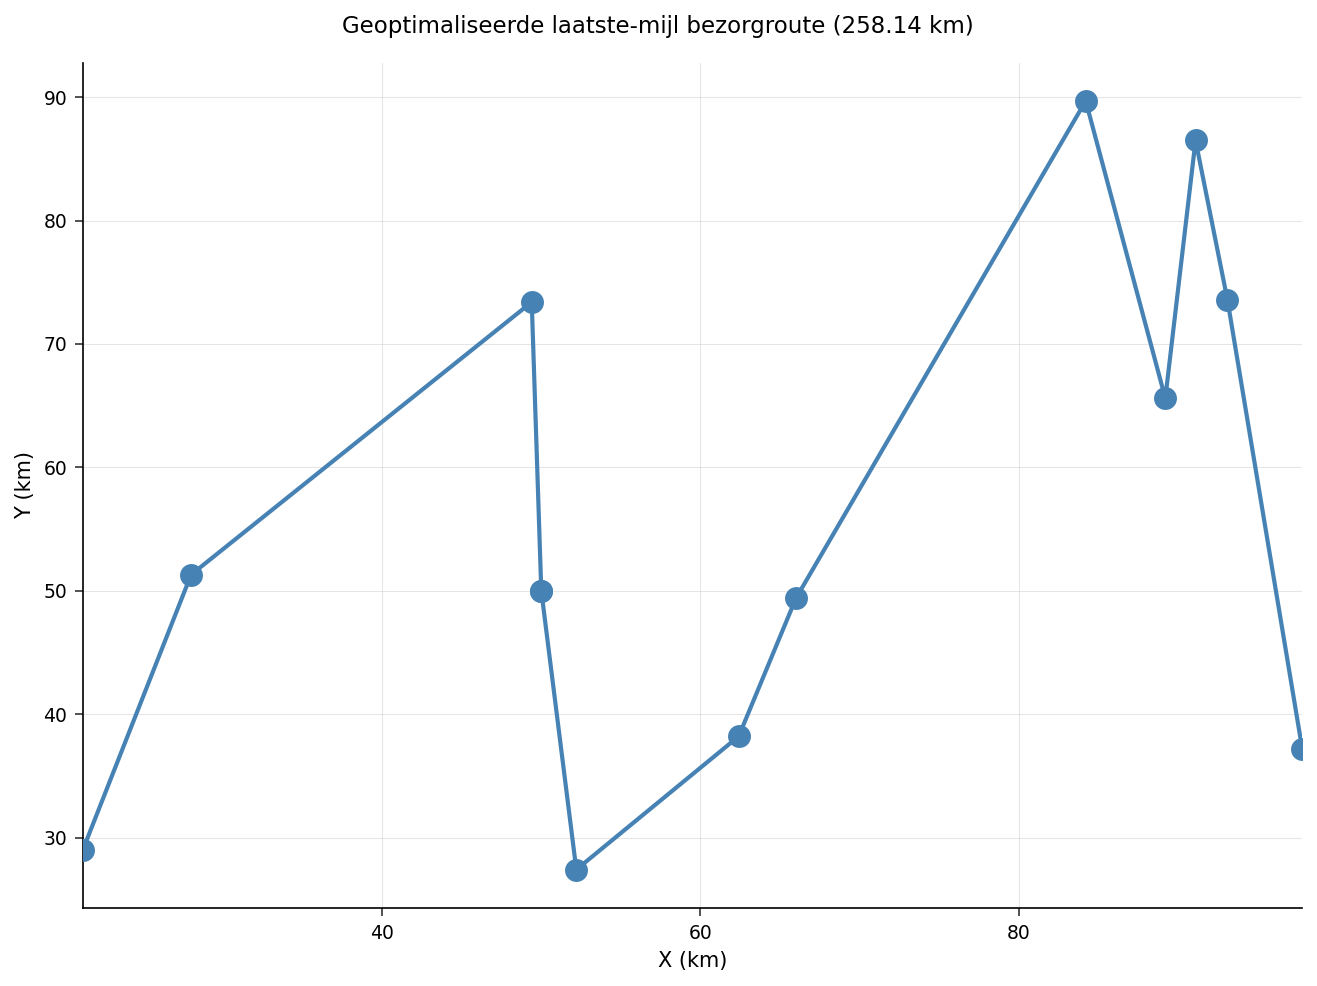

In [5]:
PROCEDURE SGPLOT GEGEVENS=route noautolegend;
    SERIES x=x y=y / LINEATTRS=(color=steelblue thickness=2);
    SCATTER x=x y=y / MARKERATTRS=(SYMBOL=circlefilled
                      color=steelblue size=10);
    XAXIS label='X (km)' grid;
    YAXIS label='Y (km)' grid;
    TITEL "Geoptimaliseerde laatste-mijl bezorgroute (&total_km km)";
UITVOEREN;

## Interpretatie van de resultaten

- **De route.** De tabellen `route` en `manifest` geven de gesloten route die
  de OPTMODEL-netwerk-TSP-oplosser heeft geproduceerd over de volledige graaf
  van 12 haltes, beginnend en eindigend bij het depot. De `Totale afstand` is
  *gemeten*: het is de som van de Euclidische afstanden per etappe (`leg_km`),
  dus die weerspiegelt de werkelijke geometrie van het netwerk in plaats van
  een aangenomen cijfer.
- **Waarom hier een netwerkoplosser.** Met 11 klanthaltes zijn er
  `11! / 2 = 19.958.400` verschillende gesloten routes, dus de planner heeft
  een algoritme nodig in plaats van opsomming. `SOLVE WITH NETWORK / TSP`
  construeert een route rechtstreeks uit de gewogen kantenverzameling zonder
  dat de analist de zoektocht handmatig hoeft te coderen.
- **Van volgorde naar manifest.** De oplosser geeft een bezoek*volgorde*
  terug; de DATA-stap zet dat om in een operationeel artefact — benoemde
  haltes, afstanden per etappe, een lopende kilometerteller en een
  eenregelig manifest dat een chauffeur kan volgen.
- **Operationele uitbreidingen.** Dezelfde OPTMODEL-opzet schaalt naar rijkere
  routering: voeg capaciteits- of tijdvensterbeperkingen toe als extra
  netwerkopties, weeg kanten op basis van rijtijd in plaats van
  hemelsbrede afstand, of verdeel haltes over meerdere voertuigen voordat je
  per voertuig een TSP oplost.